# 🎬 Netflix Customer Churn & Engagement Analysis

**Tujuan:** Memahami faktor-faktor yang memengaruhi *churn* (berhentinya pelanggan berlangganan) pada layanan streaming, berdasarkan data engagement dan profil 5.000 pelanggan.

**Dataset:** [Netflix Customer Churn & Engagement Analytics](https://www.kaggle.com/datasets/zeyadmohamed26/netflix-customer-churn-and-engagement-analytics) (Kaggle)

**Pertanyaan bisnis yang ingin dijawab:**
1. Berapa persen pelanggan yang churn?
2. Apakah tipe subscription, metode pembayaran, atau device memengaruhi churn?
3. Apakah pola engagement (jam nonton, aktivitas login) berhubungan dengan churn?
4. Faktor apa yang paling kuat berkorelasi dengan churn?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

df = pd.read_csv('netflix_customer_churn.csv')
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


## 1. Data Overview

Mengecek struktur data, tipe kolom, dan memastikan tidak ada nilai yang hilang.

In [2]:
print("Jumlah baris & kolom:", df.shape)
df.info()

Jumlah baris & kolom: (5000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int

In [3]:
# Cek missing values
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

**Insight:** Dataset berisi 5.000 baris dan 14 kolom, **tidak ada missing value** — data sudah bersih dan siap dianalisis langsung.

Kolom utama:
- `churned`: target (1 = berhenti berlangganan, 0 = masih aktif)
- Profil: `age`, `gender`, `region`, `number_of_profiles`
- Engagement: `watch_hours`, `avg_watch_time_per_day`, `last_login_days`, `favorite_genre`, `device`
- Bisnis: `subscription_type`, `monthly_fee`, `payment_method`


## 2. Distribusi Churn

Seberapa besar proporsi pelanggan yang churn vs yang masih aktif?

churned
1    50.3
0    49.7
Name: proportion, dtype: float64


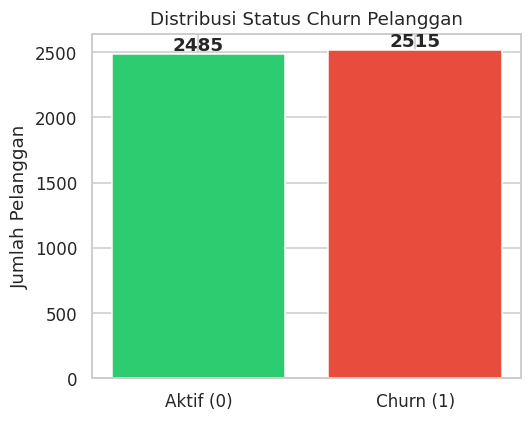

In [4]:
churn_counts = df['churned'].value_counts(normalize=True) * 100
print(churn_counts)

plt.figure(figsize=(5,4))
counts = df['churned'].value_counts().sort_index()
plt.bar(['Aktif (0)','Churn (1)'], counts.values, color=['#2ecc71','#e74c3c'])
for i,v in enumerate(counts.values):
    plt.text(i, v+30, str(v), ha='center', fontweight='bold')
plt.title('Distribusi Status Churn Pelanggan')
plt.ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

**Insight:** Distribusi churn cukup seimbang — sekitar **50,3% pelanggan churn** dan 49,7% masih aktif. Dataset ini balanced, jadi tidak perlu teknik penyeimbangan data khusus jika nanti dipakai untuk modeling.

## 3. Churn berdasarkan Tipe Subscription

Apakah pelanggan Basic, Standard, atau Premium punya kecenderungan churn yang berbeda?

subscription_type
Basic       0.618302
Standard    0.454435
Premium     0.437094
Name: churned, dtype: float64


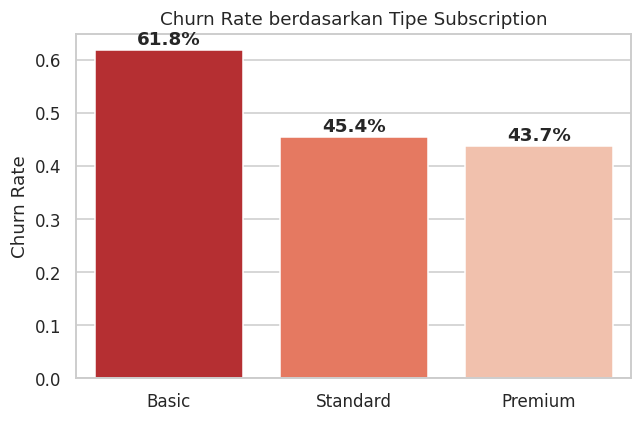

In [5]:
order = df.groupby('subscription_type')['churned'].mean().sort_values(ascending=False)
print(order)

plt.figure(figsize=(6,4))
sns.barplot(x=order.index, y=order.values, hue=order.index, palette='Reds_r', legend=False)
plt.title('Churn Rate berdasarkan Tipe Subscription')
plt.ylabel('Churn Rate')
plt.xlabel('')
for i,v in enumerate(order.values):
    plt.text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Pelanggan **Basic** punya churn rate tertinggi (**61,8%**), jauh di atas Standard (45,4%) dan Premium (43,7%).

Kemungkinan penyebab: pelanggan Basic mungkin kurang "terikat" secara value (fitur terbatas), atau menggunakan paket ini sebagai percobaan jangka pendek. Ini sinyal bahwa **program retensi bisa difokuskan ke segmen Basic**.

## 4. Churn berdasarkan Metode Pembayaran

Menariknya, metode pembayaran ternyata cukup berpengaruh.

payment_method
Crypto         0.596985
Gift Card      0.577869
PayPal         0.470760
Debit Card     0.436893
Credit Card    0.435766
Name: churned, dtype: float64


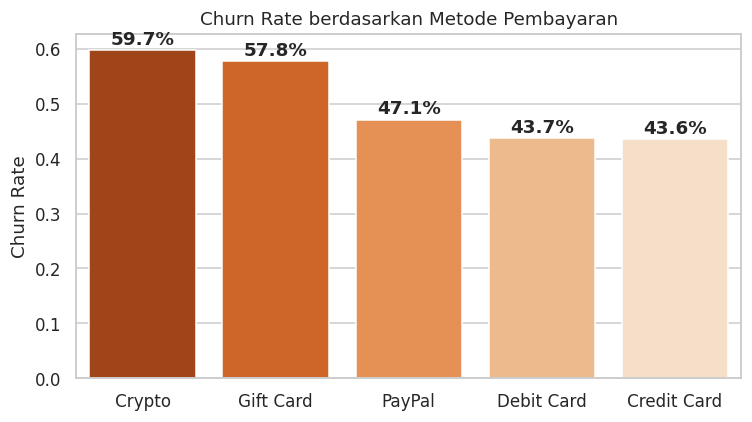

In [6]:
order = df.groupby('payment_method')['churned'].mean().sort_values(ascending=False)
print(order)

plt.figure(figsize=(7,4))
sns.barplot(x=order.index, y=order.values, hue=order.index, palette='Oranges_r', legend=False)
plt.title('Churn Rate berdasarkan Metode Pembayaran')
plt.ylabel('Churn Rate')
plt.xlabel('')
for i,v in enumerate(order.values):
    plt.text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Pengguna **Crypto (59,7%)** dan **Gift Card (57,8%)** punya churn rate jauh lebih tinggi dibanding **Credit Card (43,6%)** dan **Debit Card (43,7%)**.

Interpretasi bisnis: metode pembayaran non-recurring (gift card, crypto) cenderung tidak ter-auto-renewal, sehingga pelanggan lebih mudah berhenti begitu saldo/promo habis. Sementara kartu kredit/debit biasanya di-setting untuk auto-billing, membuat pelanggan "bertahan secara pasif".

## 5. Engagement: Watch Hours & Last Login Days

Apakah pelanggan yang jarang nonton atau jarang login lebih cenderung churn?

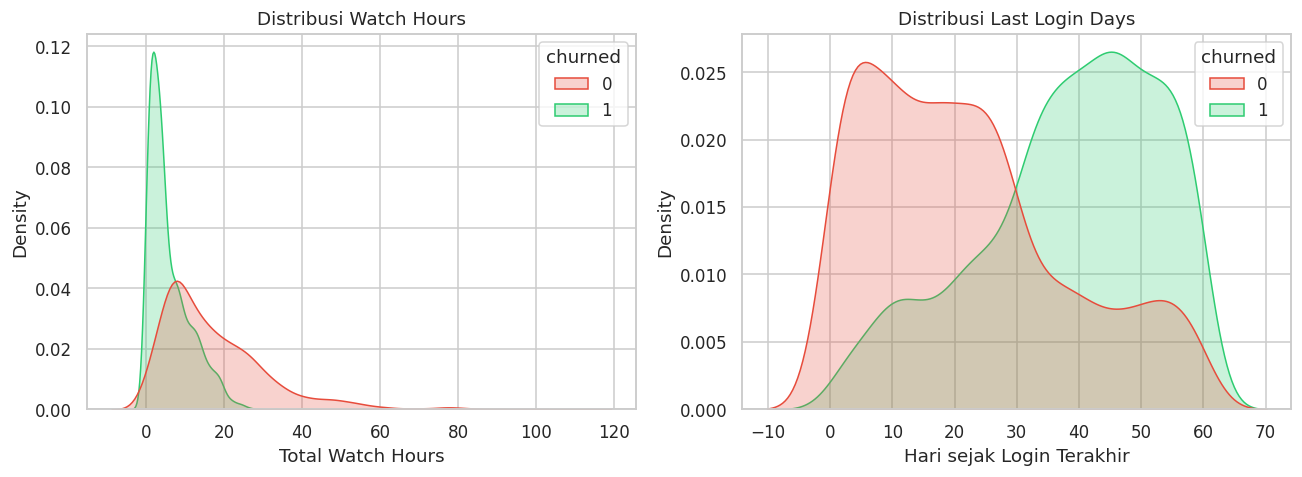

,watch_hours,last_login_days,avg_watch_time_per_day
churned,,,
0,17.449590,21.771026,1.594133
1,5.918497,38.309344,0.164048


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

sns.kdeplot(data=df, x='watch_hours', hue='churned', fill=True, common_norm=False, palette=['#e74c3c','#2ecc71'], ax=axes[0])
axes[0].set_title('Distribusi Watch Hours')
axes[0].set_xlabel('Total Watch Hours')

sns.kdeplot(data=df, x='last_login_days', hue='churned', fill=True, common_norm=False, palette=['#e74c3c','#2ecc71'], ax=axes[1])
axes[1].set_title('Distribusi Last Login Days')
axes[1].set_xlabel('Hari sejak Login Terakhir')

plt.tight_layout()
plt.show()

df.groupby('churned')[['watch_hours','last_login_days','avg_watch_time_per_day']].mean()

**Insight — ini pola paling kuat di dataset:**
- Pelanggan yang **churn** rata-rata hanya menonton **5,9 jam total**, dibanding **17,4 jam** pada pelanggan aktif.
- Pelanggan yang **churn** sudah **38 hari** sejak login terakhir, dibanding **22 hari** pada pelanggan aktif.
- `avg_watch_time_per_day` pelanggan churn jauh lebih rendah (0,16 jam vs 1,59 jam).

Ini masuk akal secara bisnis: **rendahnya engagement (nonton & login) adalah sinyal awal (early warning) sebelum pelanggan benar-benar churn.**

## 6. Korelasi Antar Variabel Numerik

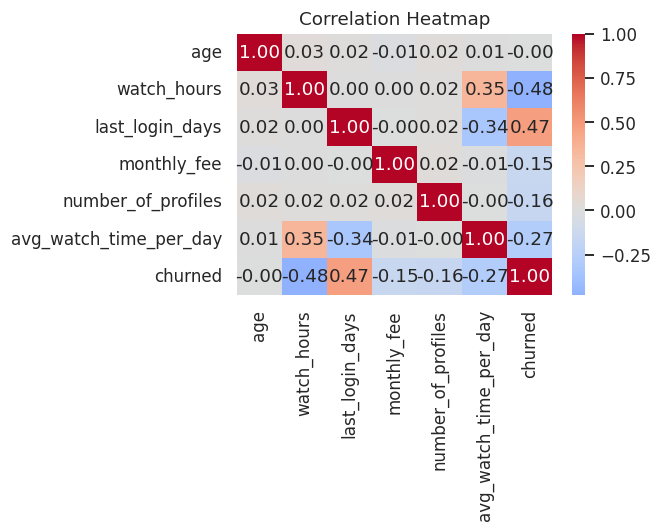

churned                   1.000000
last_login_days           0.471590
age                      -0.003515
monthly_fee              -0.152117
number_of_profiles       -0.158614
avg_watch_time_per_day   -0.272958
watch_hours              -0.479916
Name: churned, dtype: float64

In [8]:
numeric_cols = ['age','watch_hours','last_login_days','monthly_fee','number_of_profiles','avg_watch_time_per_day','churned']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr['churned'].sort_values(ascending=False)

**Insight:** Dua faktor numerik paling berkorelasi dengan churn:
- `last_login_days` → korelasi **+0.47** (semakin lama tidak login, semakin besar kemungkinan churn)
- `watch_hours` → korelasi **-0.48** (semakin sedikit menonton, semakin besar kemungkinan churn)

Sementara `age`, `region`, `device`, dan `gender` hampir tidak berpengaruh (korelasi/perbedaan sangat kecil) — jadi ini bukan faktor pembeda utama pada dataset ini.

## 7. Kesimpulan & Rekomendasi Bisnis

**Ringkasan temuan:**
1. Churn rate keseluruhan ~50%, cukup tinggi dan seimbang dengan pelanggan aktif.
2. **Engagement (watch hours & recency login)** adalah prediktor churn paling kuat — bukan demografi (usia, gender, region).
3. Pelanggan **Basic** dan pengguna metode pembayaran **non-recurring (Crypto, Gift Card)** punya risiko churn tertinggi.
4. Device dan region tidak menunjukkan perbedaan signifikan terhadap churn.

**Rekomendasi:**
- Bangun sistem *early-warning*: pelanggan dengan `last_login_days` > 30 hari dan `watch_hours` rendah bisa ditandai sebagai "berisiko churn" untuk ditargetkan kampanye re-engagement (email, notifikasi, rekomendasi konten).
- Dorong pelanggan Basic untuk upgrade paket, atau berikan insentif retensi khusus segmen ini.
- Dorong pelanggan dengan metode pembayaran non-recurring untuk beralih ke kartu debit/kredit dengan auto-renewal (misal lewat diskon kecil), karena berkorelasi dengan retensi lebih baik.

**Langkah lanjutan (opsional):** dataset ini juga siap dipakai untuk membangun **model prediksi churn** (misal Logistic Regression / Random Forest) menggunakan fitur `watch_hours`, `last_login_days`, `subscription_type`, dan `payment_method` sebagai fitur utama.
